Compare orbit integrated in external potential to galpy

In [2]:
from tambora.simulation import Sim
from galpy.potential import NFWPotential, KuzminDiskPotential, TriaxialNFWPotential
from galpy.orbit import Orbit
from galpy.util.coords import cyl_to_rect, cyl_to_rect_vec
import numpy as np
import astropy.units as u
import matplotlib.pyplot as plt

plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 16
plt.rcParams['xtick.labelsize'] = 18 
plt.rcParams['ytick.labelsize'] = 18
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.top'] = True
plt.rcParams['mathtext.fontset'] = 'stix'
# plt.rcParams['font.family'] = 'serif'
# plt.rcParams['font.serif'] = 'Times New Roman'
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True

In [ ]:
pot = NFWPotential(amp=1e13, a=20)
pot.turn_physical_on()


In [32]:
# Orbit integration times
t_end = 100 * u.Myr
dt = 1/128*u.Myr
ts = np.arange(0, t_end.value + dt.value, dt.value) * u.Myr

In [41]:
pot = NFWPotential(amp=1e13*u.Msun, a=20*u.kpc)#KuzminDiskPotential()#NFWPotential() #
#pot = TriaxialNFWPotential(amp=1e13*u.Msun, a=20*u.kpc, b=0.8, c=0.6)
pot.turn_physical_on()
R, vR, vT, z, vz, phi = 8., 0.1, 220.0, 0., 0.5, 0.
o_galpy = Orbit([R*u.kpc, vR*u.km/u.s, vT*u.km/u.s, z*u.kpc, vz*u.km/u.s, phi*u.rad])
o_galpy.integrate(ts, pot, method='leapfrog_c', dt=dt)
o_galpy.turn_physical_on()


In [42]:
pos = cyl_to_rect(R, phi, z)
vel = (cyl_to_rect_vec(vR, vT, vz, phi) * u.km/u.s).to(u.kpc/u.Myr).value

In [43]:
o_falcon = Sim()
o_falcon.turn_self_gravity_off()
o_falcon.add_external_pot(pot)
o_falcon.add_particles('o',[pos], [vel], np.array([1.]))
o_falcon.run(t_end.value, dt.value, dt.value, eps=0.0)

  0%|          | 0/12800 [00:00<?, ?it/s]

100%|██████████| 12800/12800 [00:06<00:00, 1870.92it/s]


In [44]:
o_falcon._positions[...,0][...,0] - o_galpy.x(ts)

array([ 0.00000000e+00, -2.93098879e-14, -7.81597009e-14, ...,
       -7.23787386e-07, -7.23934766e-07, -7.24082008e-07], shape=(12801,))

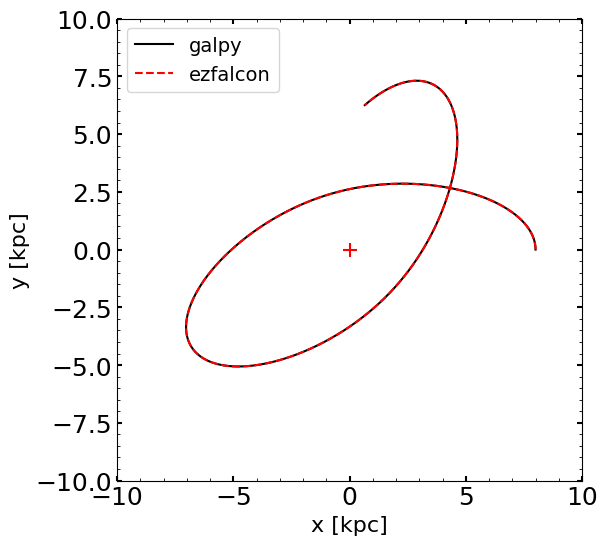

In [45]:
plt.figure(figsize=(6, 6))
plt.scatter(0,0, marker='+', s=100, c='r')
plt.xlabel('x [kpc]')
plt.ylabel('y [kpc]')
plt.xlim(-10, 10)
plt.ylim(-10, 10)
plt.plot(o_galpy.x(ts), o_galpy.y(ts), c='k', ls='-', label='galpy')
plt.plot(o_falcon.x(), o_falcon.y(), c='r', ls='--', label='tambora')
plt.legend()

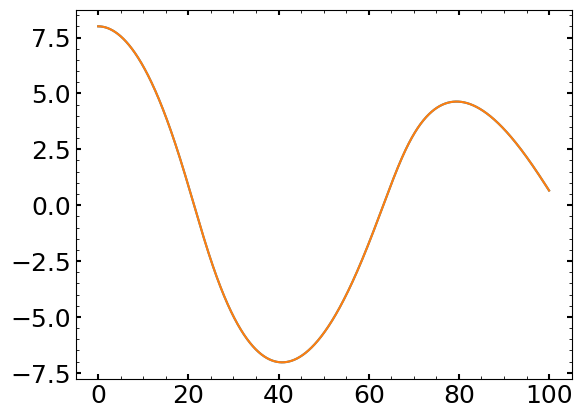

In [46]:
plt.plot(o_falcon.times, o_falcon.x())
plt.plot(ts, o_galpy.x(ts))

In [47]:
Es = []
for t in ts:
    Es.append(o_falcon.energy(t.value, eps=0.0, theta=0.0))
Es = (Es * u.kpc**2/u.Myr**2).to(u.km**2/u.s**2)

In [48]:
np.sum(o_falcon._velocities**2, axis=-1)

array([[0.05062378],
       [0.05062378],
       [0.05062392],
       ...,
       [0.17781069],
       [0.17799899],
       [0.17818743]], shape=(12801, 1))

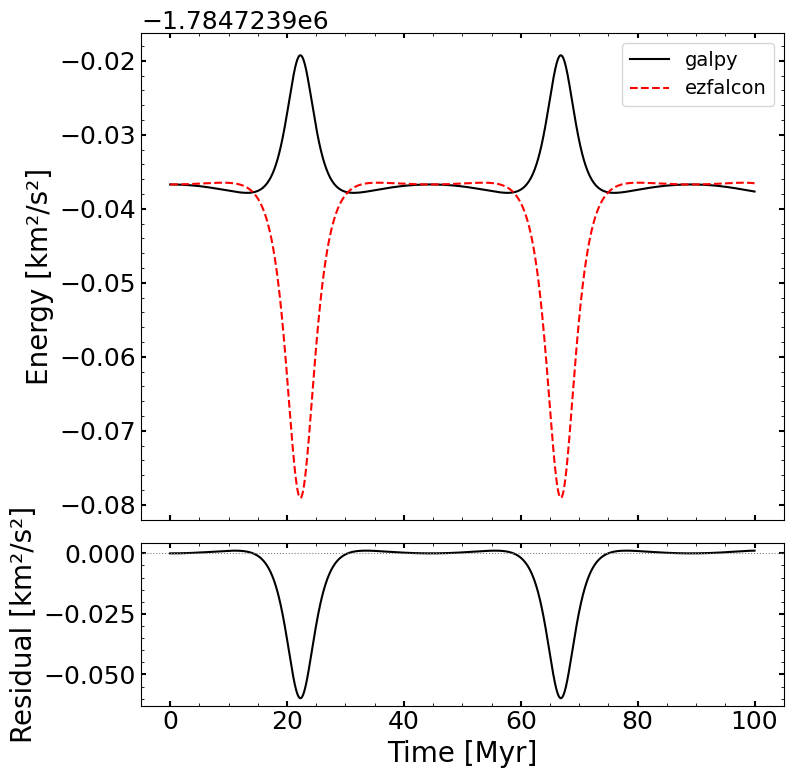

In [49]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 8), height_ratios=[3, 1], sharex=True)

# Main energy plot
ax1.plot(ts, o_galpy.E(ts, quantity=True), c='k', ls='-', label='galpy')
ax1.plot(o_falcon.times, Es, c='r', ls='--', label='tambora')

ax1.set_ylabel('Energy [km²/s²]', fontsize=20)
ax1.legend()

# Residual plot
Es_galpy_kms2 = o_galpy.E(ts, quantity=True).to(u.km**2/u.s**2)
residual = Es.flatten() - Es_galpy_kms2
ax2.plot(ts, residual, c='k', ls='-')
ax2.set_xlabel('Time [Myr]', fontsize=20)
ax2.set_ylabel('Residual [km²/s²]', fontsize=20)
ax2.axhline(0, c='gray', ls=':', lw=0.8)

plt.tight_layout()
plt.show()

<>:9: SyntaxWarning: invalid escape sequence '\D'

<>:9: SyntaxWarning: invalid escape sequence '\D'

/tmp/ipykernel_1713480/3221431851.py:9: SyntaxWarning: invalid escape sequence '\D'
  plt.ylabel('$|\Delta E / E_0|$')



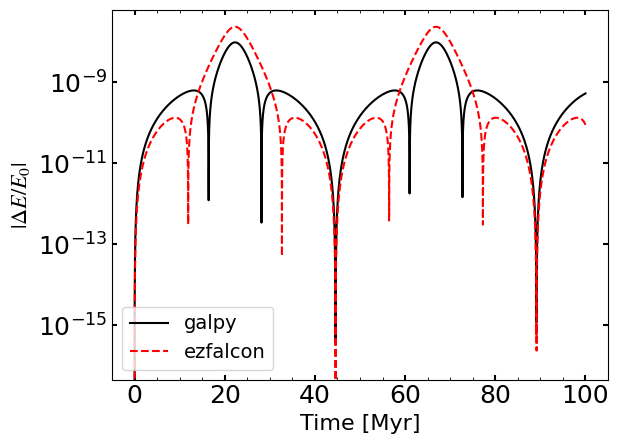

In [50]:
def galpy_dE(o, ts):
    return np.abs((o.E(ts) - o.E(0))/o.E(0))

plt.plot(ts, galpy_dE(o_galpy, ts), c='k', ls='-', label='galpy')
plt.plot(ts, o_falcon.dE(method='direct', eps=0.0), c='r', ls='--', label='tambora')

plt.yscale('log')
plt.xlabel('Time [Myr]')
plt.ylabel('$|\Delta E / E_0|$')
plt.legend()
plt.show()

# Vectorized External Potentials

In [24]:
from galpy.potential import TriaxialNFWPotential

#tnfw = TriaxialNFWPotential(amp=1e13*u.Msun, a=20*u.kpc, b=0.8, c=0.6)
tnfw = TriaxialNFWPotential(amp=1, a=2, b=0.8, c=0.6)
tnfw.turn_physical_on()
tnfw(R=np.array([8., 2., 5., 1.])*u.kpc, z=np.array([0, 1., 2., 3.])*u.kpc)

array([-11557.06141593, -13485.60121856, -12286.2618101 , -12872.97560724])

In [29]:
tnfw.rforce(R=np.array([8., 2., 5., 1.]), z=np.array([0, 1., 2., 3.]), use_physical=True, quantity=True)

<Quantity [-0.04629325, -0.17379248, -0.07353663, -0.12510921] km / (Myr s)>

In [30]:
tnfw.rforce(R=np.array([8., 2., 5., 1.]), z=np.array([0, 1., 2., 3.]))

array([-0.04629325, -0.17379248, -0.07353663, -0.12510921])